2026-04-16 19:53:00,386 - INFO - Application started.
2026-04-16 19:53:00,394 - INFO - Starting the experiment...
2026-04-16 19:53:00,400 - INFO - Starting replication 1/15
/home/xyzor/.cache/uv/builds-v0/.tmpenLlhU/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/home/xyzor/.cache/uv/builds-v0/.tmpenLlhU/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. 

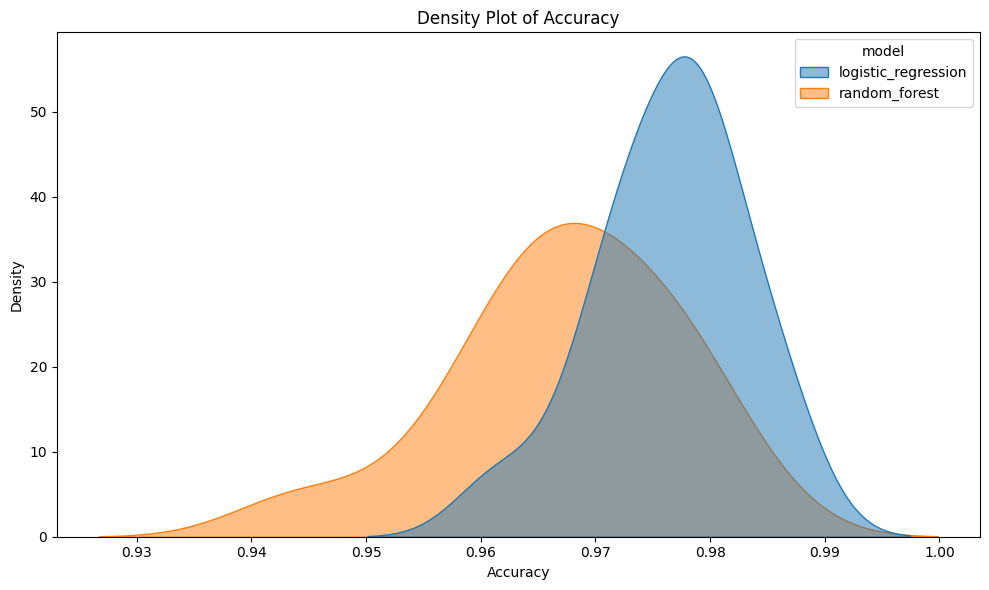

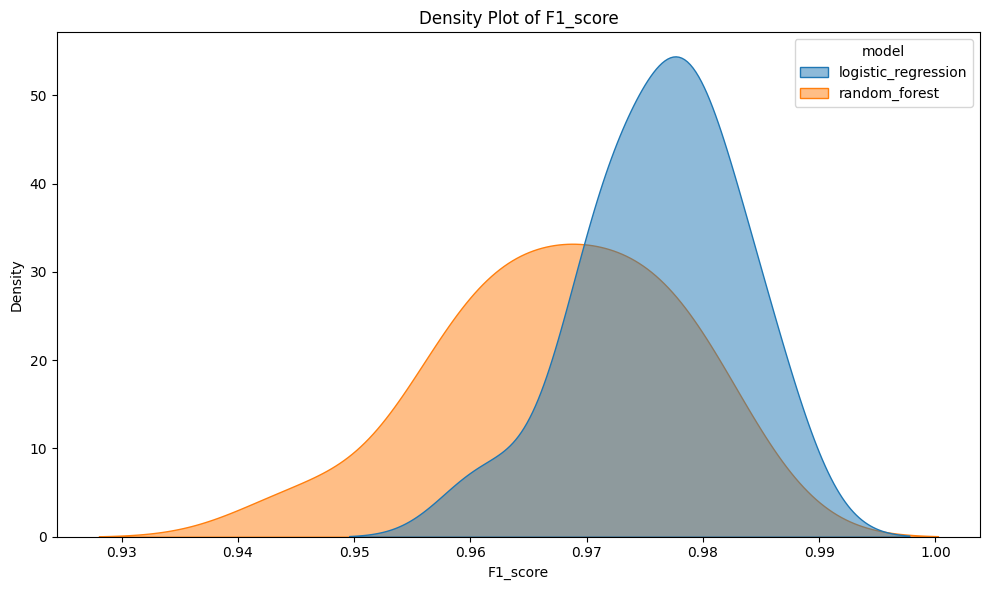

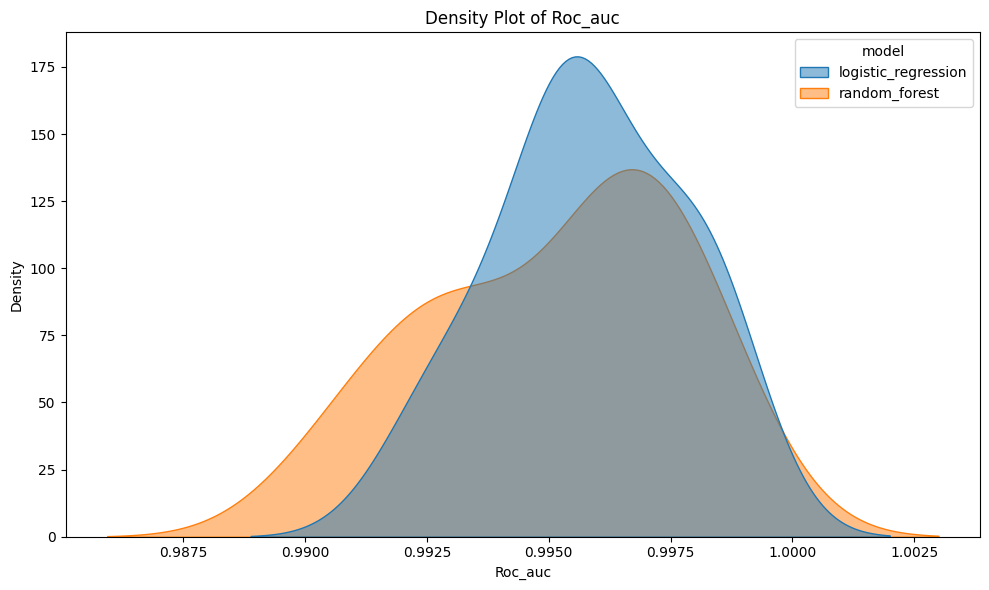

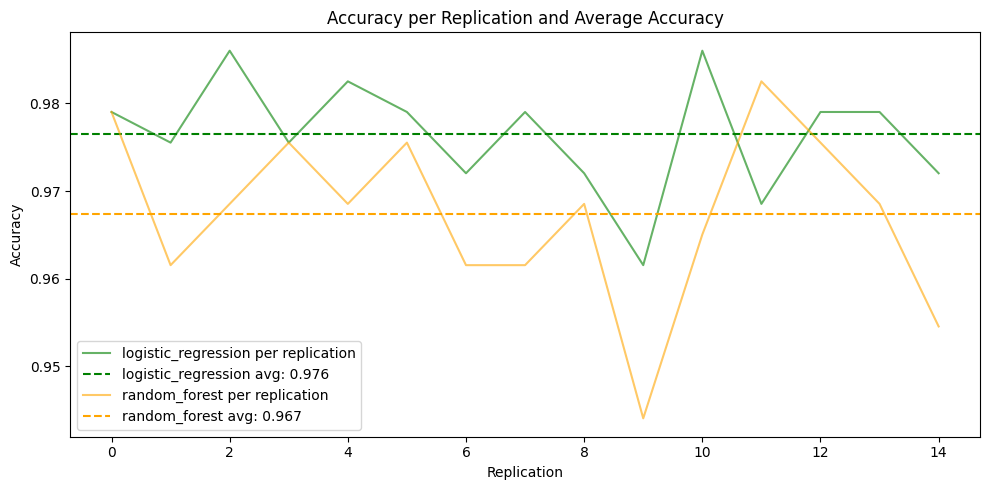

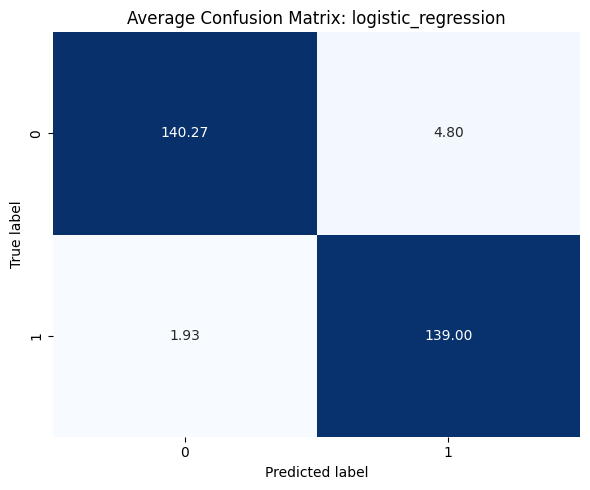

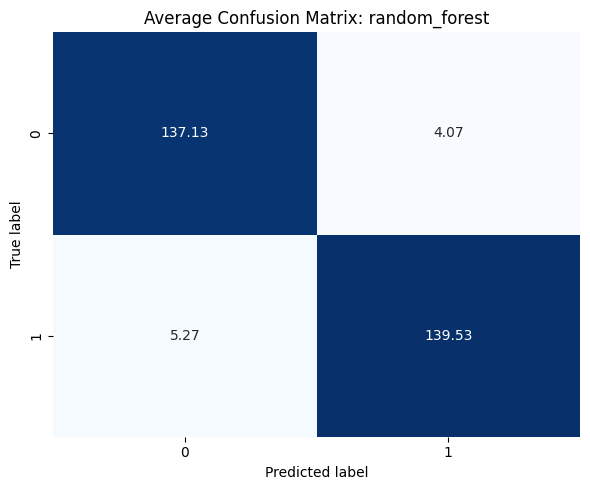

2026-04-16 19:54:15,117 - INFO - Plots generated successfully.
2026-04-16 19:54:15,117 - INFO - Application finished successfully.


Most frequently chosen best parameters for logistic_regression: {'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}
Most frequently chosen best parameters for random_forest: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}


In [1]:
import warnings

# Suppress specific FutureWarnings from scikit-learn
warnings.filterwarnings("ignore", category=FutureWarning)

from sklearn.linear_model import LogisticRegression
from data.data_handling_refactored import DatasetRefactored
from experiment.experiment import Experiment
from plotting.experiment_plotter import ExperimentPlotter
from utils.logger import Logger
from sklearn.ensemble import RandomForestClassifier


def initialize_models_and_params():
    """
    Initializes models and their hyperparameter grids.

    Returns:
    - models: dict, dictionary of model instances.
    - param_grids: dict, dictionary of hyperparameter grids.
    """
    models = {
    "logistic_regression": LogisticRegression(max_iter=5000),
    "random_forest": RandomForestClassifier()
    }
    
    param_grids = {
        "logistic_regression": {
            "C": [0.01, 0.1, 1, 10],
            "penalty": ["l2"],
            "solver": ["lbfgs"]
        },
        "random_forest": {
            "n_estimators": [50, 100, 200],
            "max_depth": [None, 5, 10, 20],
            "min_samples_split": [2, 5, 10]
        }
    }
    return models, param_grids



def run_experiment(dataset, models, param_grids, logger):
    """
    Runs the experiment with the given dataset, models, and hyperparameter grids.

    Parameters:
    - dataset: Dataset instance, the dataset to use.
    - models: dict, dictionary of model instances.
    - param_grids: dict, dictionary of hyperparameter grids.
    - logger: Logger instance, for logging messages.

    Returns:
    - experiment: Experiment instance, the experiment object.
    - results: DataFrame, the results of the experiment.
    """
    logger.info("Starting the experiment...")
    experiment = Experiment(models, param_grids, logger=logger)
    results = experiment.run(dataset.data, dataset.target)
    logger.info("Experiment completed successfully.")
    return experiment, results


def plot_results(experiment, results, logger):
    """
    Plots the results of the experiment.

    Parameters:
    - experiment: Experiment instance, the experiment object.
    - results: DataFrame, the results of the experiment.
    - logger: Logger instance, for logging messages.
    """
    logger.info("Generating plots for the experiment results...")
    plotter = ExperimentPlotter()
    plotter.plot_metric_density(results)
    plotter.plot_evaluation_metric_over_replications(
        experiment.results.groupby('model')['accuracy'].apply(list).to_dict(),
        'Accuracy per Replication and Average Accuracy', 'Accuracy')
    plotter.plot_confusion_matrices(experiment.mean_conf_matrices)
    plotter.print_best_parameters(results)
    logger.info("Plots generated successfully.")


def main():
    """
    Main function to execute the model training and evaluation pipeline.

    Initializes the dataset, defines models and their parameter grids,
    and invokes the replication of model training and evaluation.
    """
    logger = Logger(log_file="outputs/application.log")
    logger.info("Application started.")

    dataset = DatasetRefactored()
    models, param_grids = initialize_models_and_params()
    experiment, results = run_experiment(dataset, models, param_grids, logger)
    plot_results(experiment, results, logger)

    logger.info("Application finished successfully.")


if __name__ == "__main__":
    main()
